>>> Nutze TIFF als Eingangsfeld: messung 500cm.tiff


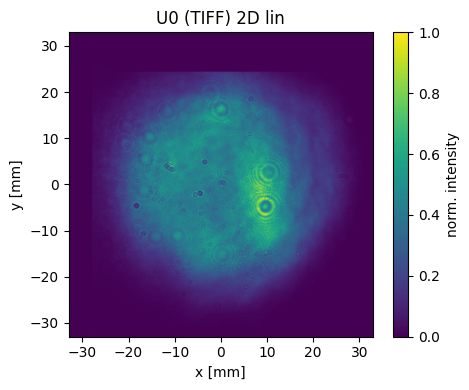

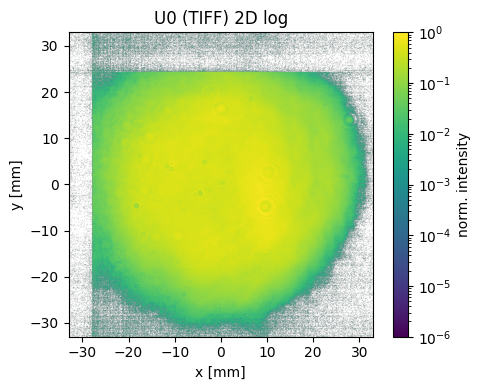

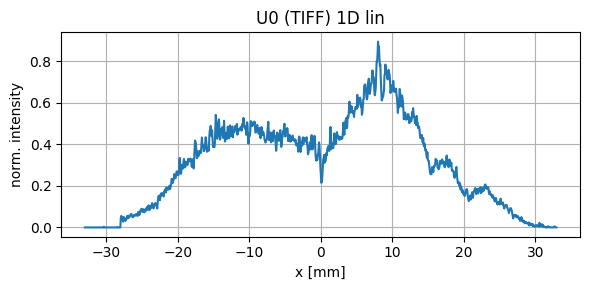

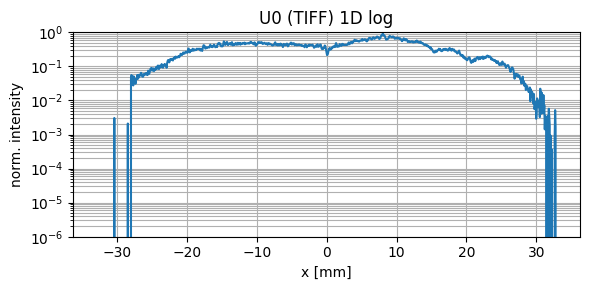

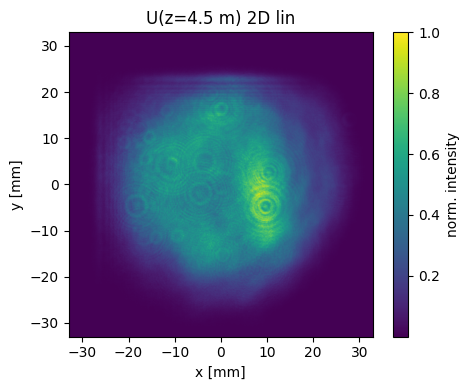

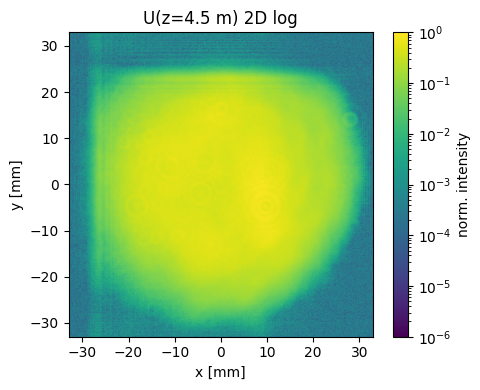

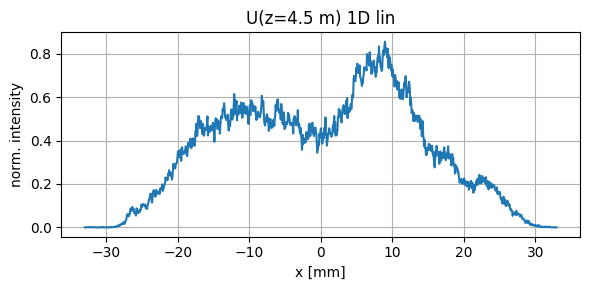

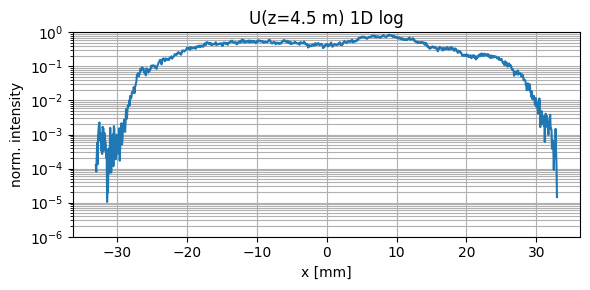

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os

# ==============================================================
# 1) Physik & Gitter
# ==============================================================
lam = 800e-9            # Wellenlänge [m]
BEAM_DIAM = 11e-3       # nur zur Plot-/Fenstergröße

N = 1024
L = 6 * BEAM_DIAM
dx = L / N
x = (np.arange(N) - N/2) * dx
y = x
X, Y = np.meshgrid(x, y)

# ==============================================================
# 2) Hilfsfunktionen: Zentrieren + Resampling
# ==============================================================
def center_by_centroid(I, thresh_rel=0.2):
    """Zentriert Intensitätsbild per Schwerpunkt oberhalb eines Thresholds (integer shift)."""
    I = np.asarray(I, float)
    if I.max() <= 0:
        return I

    t = thresh_rel * I.max()
    m = I > t
    if not np.any(m):
        return I

    yy, xx = np.indices(I.shape)
    cx = (xx[m] * I[m]).sum() / (I[m].sum() + 1e-12)
    cy = (yy[m] * I[m]).sum() / (I[m].sum() + 1e-12)

    sx = int(round(I.shape[1] / 2 - cx))
    sy = int(round(I.shape[0] / 2 - cy))
    return np.roll(np.roll(I, sy, axis=0), sx, axis=1)

def resample_bilinear(img, new_h, new_w):
    """NumPy-only bilinear resampling: (h,w)->(new_h,new_w)."""
    h, w = img.shape
    if (h, w) == (new_h, new_w):
        return img.copy()

    yy = np.linspace(0, h - 1, new_h)
    xx = np.linspace(0, w - 1, new_w)

    x0 = np.floor(xx).astype(int)
    x1 = np.clip(x0 + 1, 0, w - 1)
    y0 = np.floor(yy).astype(int)
    y1 = np.clip(y0 + 1, 0, h - 1)

    wx = (xx - x0)[None, :]
    wy = (yy - y0)[:, None]

    Ia = img[y0[:, None], x0[None, :]]
    Ib = img[y0[:, None], x1[None, :]]
    Ic = img[y1[:, None], x0[None, :]]
    Id = img[y1[:, None], x1[None, :]]

    return (1 - wy) * ((1 - wx) * Ia + wx * Ib) + wy * ((1 - wx) * Ic + wx * Id)

# ==============================================================
# 3) TIFF -> Eingangsfeld U0 (ohne harte Maske!)
# ==============================================================
def load_tiff_intensity(filename):
    if not os.path.exists(filename):
        raise FileNotFoundError(f"{filename} nicht gefunden!")

    # TIFF laden
    try:
        import tifffile
        img = tifffile.imread(filename)
    except Exception:
        from PIL import Image
        img = np.array(Image.open(filename))

    img = np.asarray(img)

    # RGB -> gray
    if img.ndim == 3:
        if img.shape[-1] in (3, 4):
            img = img[..., :3].mean(axis=-1)
        else:
            # z.B. (frames, h, w) -> nimm erstes
            img = img[0]

    I = img.astype(np.float64)

    # Robustes Background vom Rand (kein min!)
    edge = max(10, int(0.03 * min(I.shape)))  # ~3% Rand
    border = np.concatenate([
        I[:edge, :].ravel(),
        I[-edge:, :].ravel(),
        I[:, :edge].ravel(),
        I[:, -edge:].ravel(),
    ])
    bg = np.median(border)

    I = I - bg
    I[I < 0] = 0.0

    # Zentrieren
    I = center_by_centroid(I, thresh_rel=0.2)

    # Normieren
    peak = I.max()
    if peak > 0:
        I /= peak

    # Auf Simulationsgitter bringen
    if I.shape != (N, N):
        I = resample_bilinear(I, N, N)

    return I

def make_input_field_from_tiff(filename="messung 52cm.tiff"):
    print(f">>> Nutze TIFF als Eingangsfeld: {filename}")
    I = load_tiff_intensity(filename)

    # Intensität -> Feldamplitude (Phase = 0)
    U0 = np.sqrt(I).astype(np.complex128)
    return U0

# ==============================================================
# 4) Angular Spectrum Propagation
# ==============================================================
def propagate_asm(U0, z):
    k = 2*np.pi / lam

    fx = np.fft.fftfreq(N, d=dx)
    fy = np.fft.fftfreq(N, d=dx)
    FX, FY = np.meshgrid(fx, fy)

    kx = 2*np.pi * FX
    ky = 2*np.pi * FY
    kz = np.sqrt(k**2 - kx**2 - ky**2 + 0j)

    H = np.exp(1j * kz * z)

    U_k = np.fft.fft2(U0)
    Uz = np.fft.ifft2(U_k * H)
    return Uz

# ==============================================================
# 5) Plot-Funktionen
# ==============================================================
def plot_2d(U, title="", zoom_mm=None, log=False):
    I = np.abs(U)**2
    I /= I.max() if I.max() > 0 else 1

    x_mm = x * 1e3

    if zoom_mm is None:
        I_show = I
        extent = [x_mm.min(), x_mm.max(), x_mm.min(), x_mm.max()]
    else:
        m = np.abs(x_mm) <= zoom_mm
        I_show = I[np.ix_(m, m)]
        extent = [-zoom_mm, zoom_mm, -zoom_mm, zoom_mm]

    plt.figure(figsize=(5,4))
    if log:
        plt.imshow(I_show, extent=extent, origin="lower",
                   norm=LogNorm(vmin=1e-6, vmax=1), aspect="equal")
    else:
        plt.imshow(I_show, extent=extent, origin="lower", aspect="equal")

    plt.xlabel("x [mm]")
    plt.ylabel("y [mm]")
    plt.title(title)
    plt.colorbar(label="norm. intensity")
    plt.tight_layout()
    plt.show()


def plot_1d(U, title="", zoom_mm=None, log=False):
    I = np.abs(U)**2
    I /= I.max() if I.max() > 0 else 1

    mid = N//2
    I1d = I[mid, :]
    x_mm = x * 1e3

    if zoom_mm is None:
        x_plot = x_mm
        I_plot = I1d
    else:
        m = np.abs(x_mm) <= zoom_mm
        x_plot = x_mm[m]
        I_plot = I1d[m]

    plt.figure(figsize=(6,3))
    plt.plot(x_plot, I_plot)
    if log:
        plt.yscale("log")
        plt.ylim(1e-6, 1)

    plt.xlabel("x [mm]")
    plt.ylabel("norm. intensity")
    plt.title(title)
    plt.grid(True, which="both")
    plt.tight_layout()
    plt.show()


# ==============================================================
# 6) Demo
# ==============================================================
if __name__ == "__main__":

    U0 = make_input_field_from_tiff("messung 500cm.tiff")

    z = 4.5
    Uz = propagate_asm(U0, z)

    plot_2d(U0, "U0 (TIFF) 2D lin", zoom_mm=None, log=False)
    plot_2d(U0, "U0 (TIFF) 2D log", zoom_mm=None, log=True)
    plot_1d(U0, "U0 (TIFF) 1D lin", zoom_mm=None, log=False)
    plot_1d(U0, "U0 (TIFF) 1D log", zoom_mm=None, log=True)

    plot_2d(Uz, f"U(z={z} m) 2D lin", zoom_mm=None, log=False)
    plot_2d(Uz, f"U(z={z} m) 2D log", zoom_mm=None, log=True)
    plot_1d(Uz, f"U(z={z} m) 1D lin", zoom_mm=None, log=False)
    plot_1d(Uz, f"U(z={z} m) 1D log", zoom_mm=None, log=True)
